# Loan Approval Prediction Machine Learning Project


### 1. Install and Import Libraries


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Data Exploration & Exploratory Data Analysis (EDA)
We load the dataset `train_u6lujuX_CVtuZ9i.csv` and inspect its shape, structure, data types, missing values, duplicates, and summary statistics.


In [15]:
# Load the dataset
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 614 rows, 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.00000,NaN,360.00000,1.00000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.00000,128.00000,360.00000,1.00000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.00000,66.00000,360.00000,1.00000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.00000,120.00000,360.00000,1.00000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.00000,141.00000,360.00000,1.00000,Urban,Y


### 2.1 Dataset Structure, Summary Statistics & Missing Values


In [16]:

print("Dataset Information")
df.info()

print("\n\n")
print("Summary Statistics (Numerical Features)")
print(df.describe())

print("\n\n")
print("Summary Statistics (Categorical Features")
print(df.describe(include=['O']))

print("\n\n")
print(" Missing Values Count ")
print(df.isnull().sum())

print("\n\n")
print("Duplicate Rows Check ")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB



Summary Statistics (Numerical Features)
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amou

C:\Users\thisu\AppData\Local\Temp\ipykernel_21720\4275546130.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['O']))


### 2.2 Visualizing Categorical Variables & Target Class Balance
We plot categorical variables against the target `Loan_Status` to check for class balance and bivariate trends.


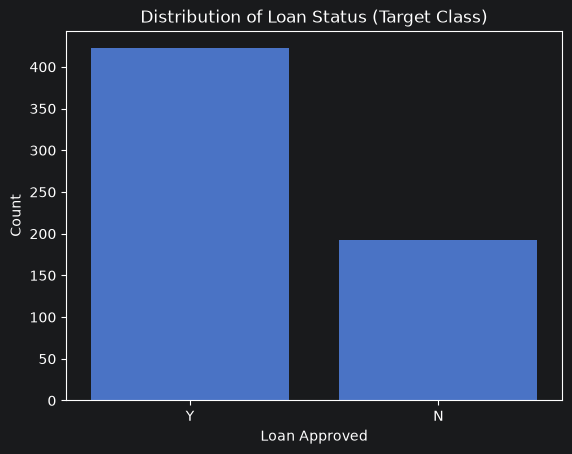

Class Proportions:
Loan_Status
Y   0.68730
N   0.31270
Name: proportion, dtype: float64


In [17]:

sns.countplot(x='Loan_Status', data=df, )
plt.title('Distribution of Loan Status (Target Class)')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

# Print class counts
print("Class Proportions:")
print(df['Loan_Status'].value_counts(normalize=True))

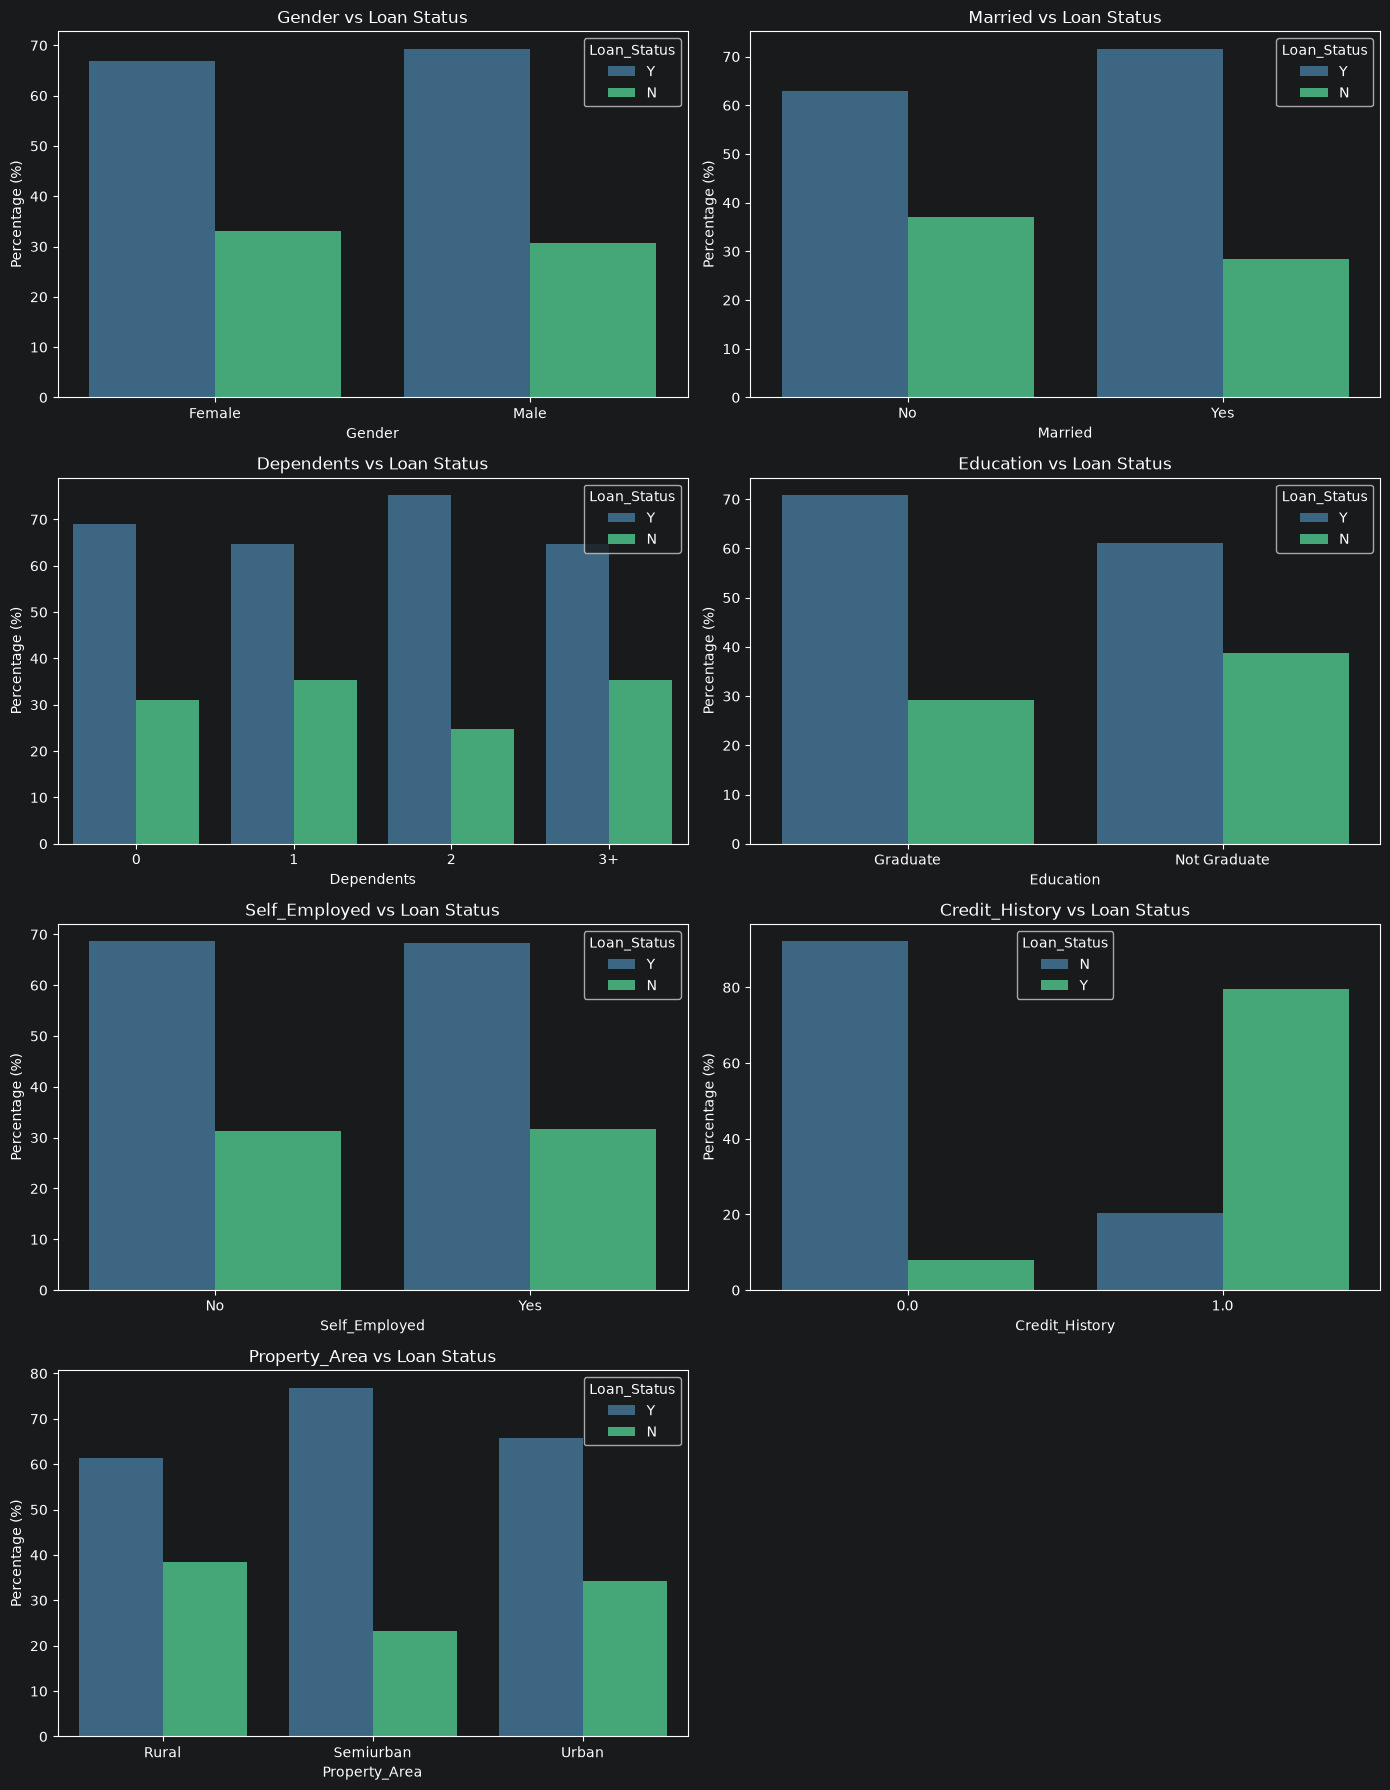

In [18]:
# Plot other categorical variables against Loan Status as percentages
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate percentage of Loan_Status within each category
    prop_df = df.groupby(col)['Loan_Status'].value_counts(normalize=True).rename('Percentage').mul(100).reset_index()
    sns.barplot(x=col, y='Percentage', hue='Loan_Status', data=prop_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')

# Hide the last empty axis
fig.delaxes(axes[-1])
plt.tight_layout()

plt.show()

### 2.3 Visualizing Numerical Distributions & Outliers
We visualize numerical features to check for distribution shape, skewness, and outliers.


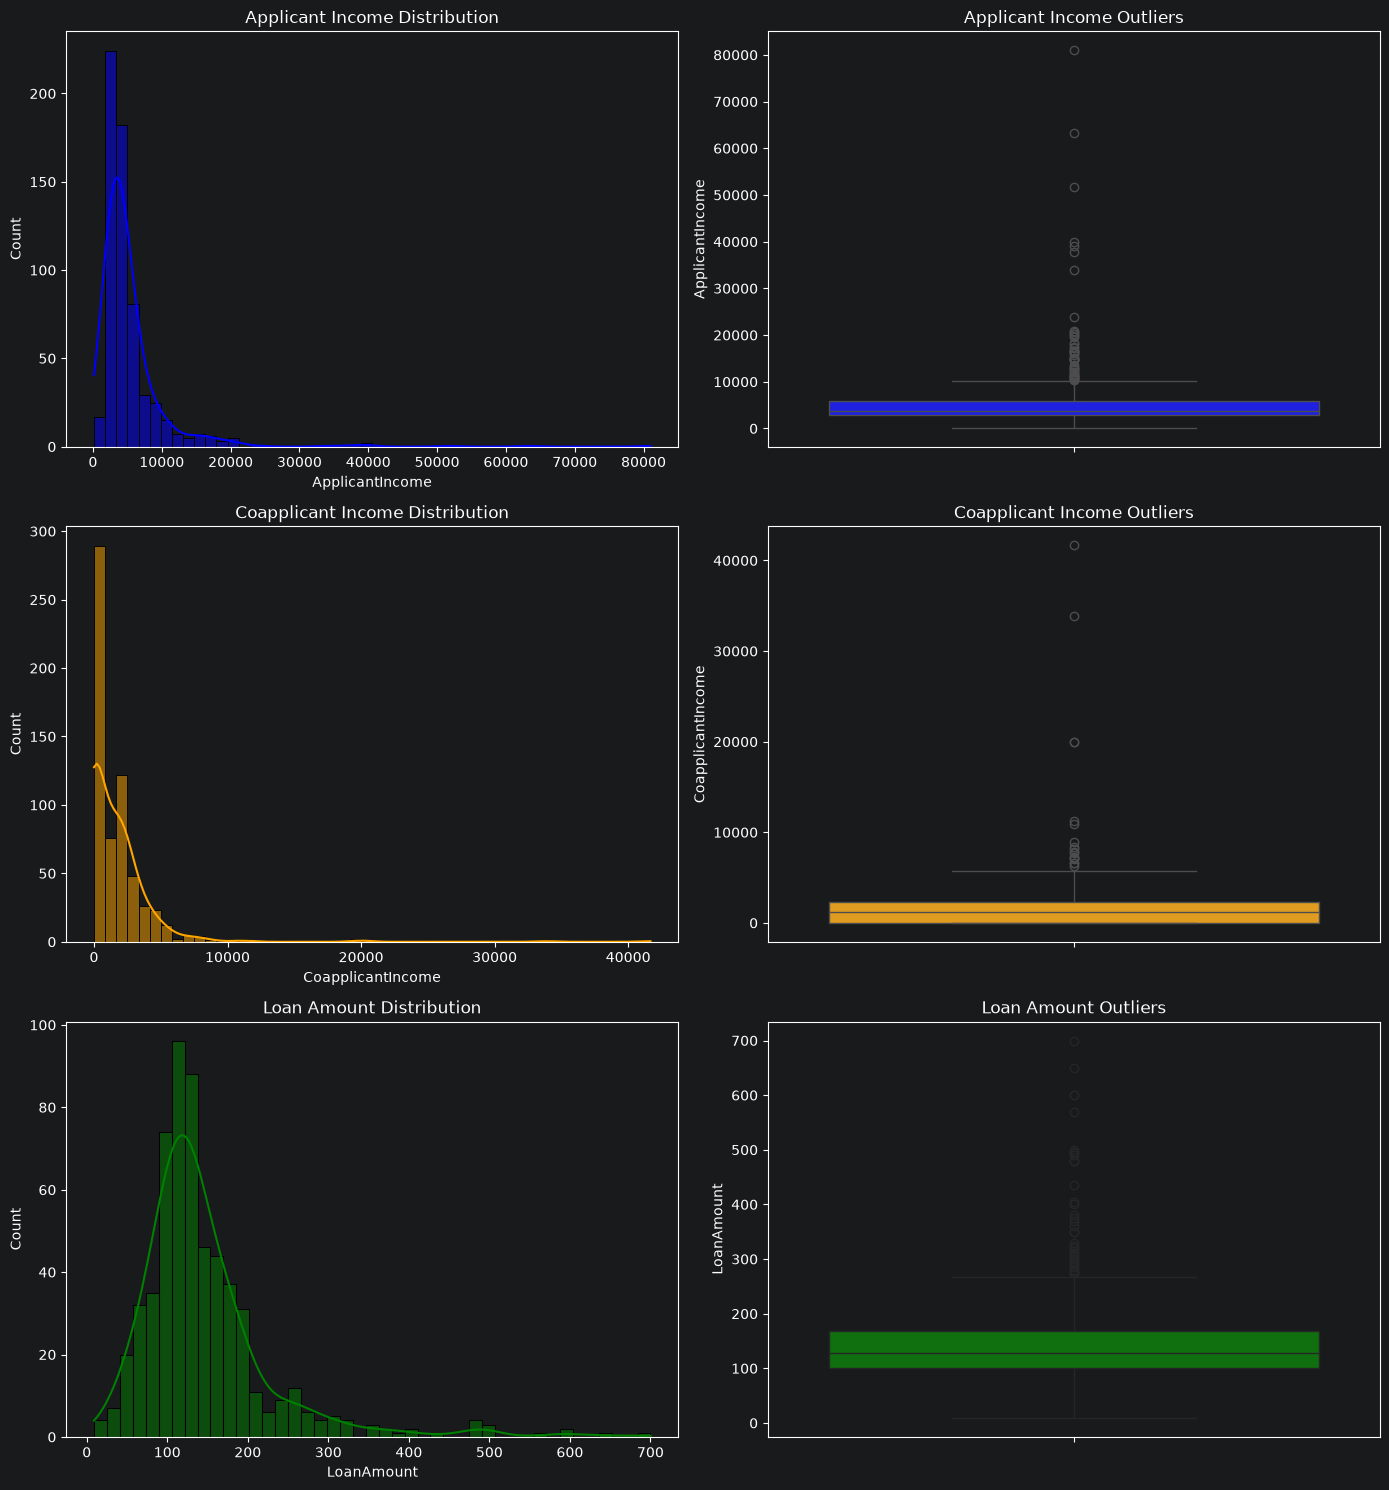

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# ApplicantIncome
sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Applicant Income Distribution')
sns.boxplot(y=df['ApplicantIncome'], ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Applicant Income Outliers')

# CoapplicantIncome
sns.histplot(df['CoapplicantIncome'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Coapplicant Income Distribution')
sns.boxplot(y=df['CoapplicantIncome'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Coapplicant Income Outliers')

# LoanAmount
sns.histplot(df['LoanAmount'].dropna(), kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('Loan Amount Distribution')
sns.boxplot(y=df['LoanAmount'].dropna(), ax=axes[2, 1], color='green')
axes[2, 1].set_title('Loan Amount Outliers')

plt.tight_layout()

plt.show()

## 3. Data Preprocessing & Feature Engineering
We clean the data by filling missing values (mode for categorical, median for numerical), creating a TotalIncome feature, applying log transformation to skew variables, encoding categorical columns, and dropping redundant features.


In [20]:
# Impute categorical variables with Mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute numerical variables with Median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Verify no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [21]:
# Feature Engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['TotalIncome_Log'] = np.log(df['TotalIncome'])
df['LoanAmount_Log'] = np.log(df['LoanAmount'])

# Categorical mapping
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# One-hot encoding for Property_Area (dropping first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

# Drop redundant features and Loan_ID
df_cleaned = df.drop(columns=['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome'])

df_cleaned.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome_Log,LoanAmount_Log,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,360.00000,1.00000,1,8.67403,4.85203,False,True
1,1,1,1,1,0,360.00000,1.00000,0,8.71457,4.85203,False,False
2,1,1,0,1,1,360.00000,1.00000,1,8.00637,4.18965,False,True
3,1,1,0,0,0,360.00000,1.00000,1,8.50532,4.78749,False,True
4,1,0,0,1,0,360.00000,1.00000,1,8.69951,4.94876,False,True


### 3.1 Bivariate Correlation Analysis
We plot a correlation matrix heatmap to check linear relationships between features and the target.


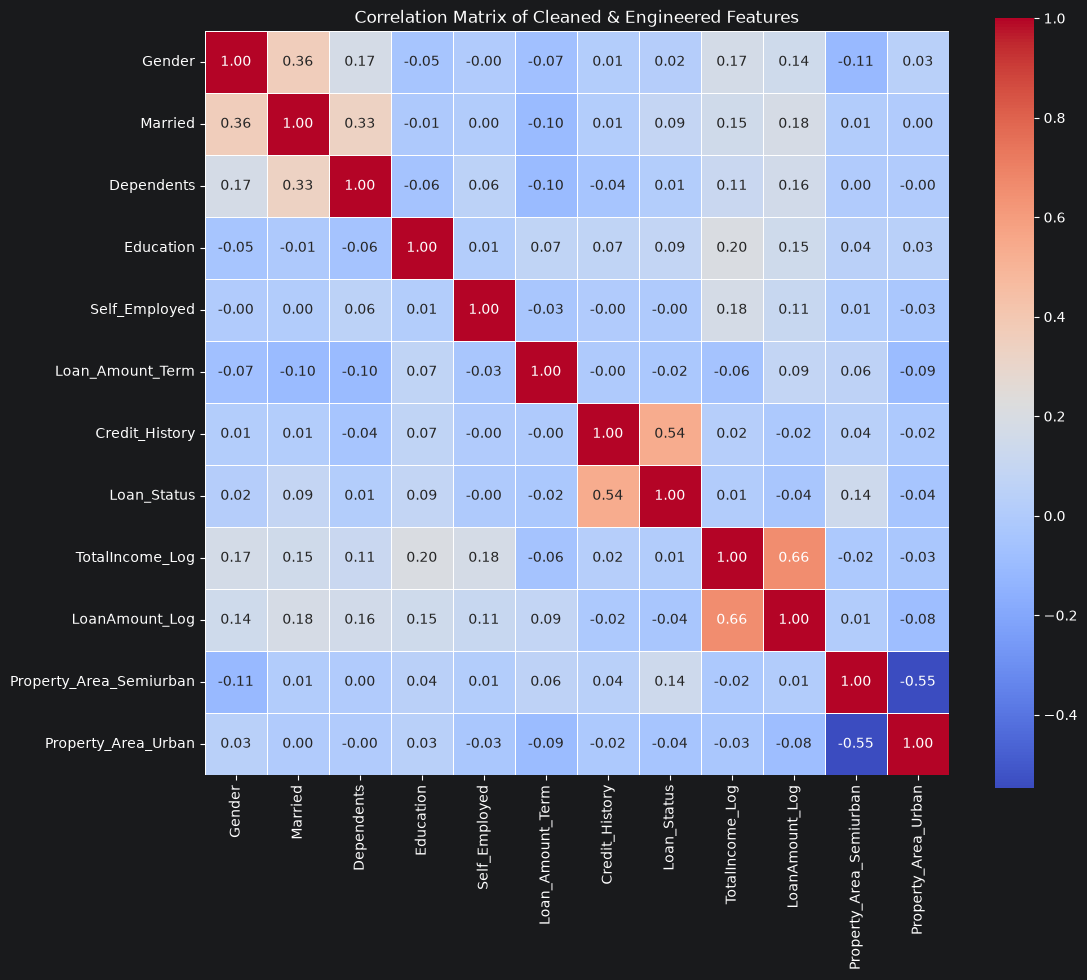

In [22]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Cleaned & Engineered Features')
plt.show()

### 3.2 Splitting & Scaling Features
We split the data into 80% training and 20% test sets, then scale continuous features using StandardScaler.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_cleaned.drop(columns=['Loan_Status'])
y = df_cleaned['Loan_Status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set size: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Test set size: {X_test_scaled.shape[0]} samples, {X_test_scaled.shape[1]} features")

Train set size: 491 samples, 11 features
Test set size: 123 samples, 11 features


## 4. Model Building 

We train Logistic Regression, KNN , and Random Forest models (using GridSearchCV with 5-fold cross-validation to optimize hyperparameters).


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. KNN Classifier (Default k=5)
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_scaled, y_train)

# 3. Random Forest (Default)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_scaled, y_train)

# 4. Random Forest Hyperparameter Tuning
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

print("Optimization Results ")
print("Best Random Forest Parameters:", rf_grid.best_params_)

Optimization Results 
Best Random Forest Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


## 5. Model Evaluation & Comparison
We evaluate the models on the test set using Accuracy, Precision, Recall, F1-Score, Confusion Matrices, and ROC-AUC curves.


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

models = {
    'Logistic Regression': lr_model,
    'K-Nearest Neighbors': best_knn,
    'Random Forest (Default)': rf_default,
    'Random Forest (Tuned)': best_rf
}

results = {}

for name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# Create a comparison dataframe
results_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
results_df = results_df.round(4)
results_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.85366,0.83168,0.98824,0.90323
K-Nearest Neighbors,0.82927,0.82653,0.95294,0.88525
Random Forest (Default),0.83740,0.85714,0.91765,0.88636
Random Forest (Tuned),0.86179,0.84000,0.98824,0.90811


### 5.1 Visualizing Confusion Matrices
We plot confusion matrices to see the breakdown of correct and incorrect predictions for each model.


IndexError: index 3 is out of bounds for axis 0 with size 3

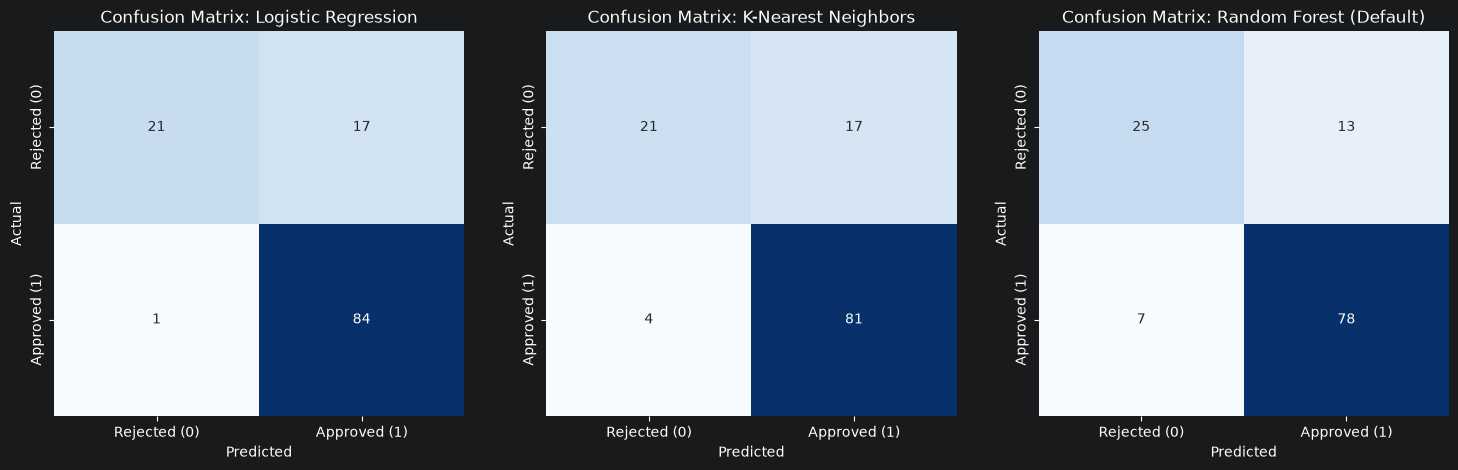

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Rejected (0)', 'Approved (1)'], yticklabels=['Rejected (0)', 'Approved (1)'])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()

plt.show()

### 5.2 Visualizing ROC-AUC Curves
We plot ROC curves and calculate AUC scores to compare the models' ability to separate the classes.


In [ ]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

### 5.3 Feature Importance (Random Forest)
We plot the feature importance from Random Forest to see which variables are most predictive.


In [ ]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices],
    y=feature_names[indices],
    hue=feature_names[indices],
    palette='viridis',
    legend=False
)
plt.title('Feature Importances via Random Forest')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

## 6. Interpretation of Results & Conclusion
- **Credit History**: This is the single most important predictor of loan approval.
- **Model Performance**: Logistic Regression and Random Forest achieve the highest accuracy (~84.5%), while KNN performs slightly lower.
-